# Mục đích
**Sử dụng minifest ở file 01 và datasetCWRU**
- **Thực hiện đúng các bước tính toán - Tường minh từng bước**
- **Kiểm tra xem DSP - HYBRID có giống như lý thuyết đã tính toán?**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfilt
# --- NẠP THÔNG SỐ TỪ DỰ ÁN ---
from common.config import SCOPE, RESONANCE_BAND_HZ, LP_CUTOFF_HZ, NOMINAL_RPM_BY_LOAD, bearing_fault_frequencies
from common.dsp import (ALPHA_MAX_MINMAX, BETA_MIN_MINMAX,
                        BENCHMARK_BANDPASS_ORDER, BENCHMARK_LOWPASS_ORDER,
                        hybrid_envelope, compute_fft)
from common import pipeline, io_utils

# Cấu hình đồ họa
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True

fs = float(SCOPE["sampling_rate_hz"])  # 12000.0
fc = (RESONANCE_BAND_HZ[0] + RESONANCE_BAND_HZ[1]) / 2.0

In [2]:
from pathlib import Path
REAL_DATA_ROOT = Path("../../data/raw")    # thư mục gốc chứa cây .mat CWRU
OUTPUT_DIR = Path("../outputs")           # nơi cache manifest.csv

manifest_full = pipeline.get_manifest(
    use_synthetic=False,
    real_data_root=REAL_DATA_ROOT,
    synthetic_data_root=None,
    output_dir=OUTPUT_DIR,
)
manifest = io_utils.apply_scope_filter(manifest_full)
print(f"Manifest: {len(manifest_full)} file gốc -> {len(manifest)} file trong phạm vi (không cảnh báo).")
manifest.head()

Manifest: 161 file gốc -> 40 file trong phạm vi (không cảnh báo).


,file_path,load_hp,label,fault_diameter_mils,or_position,source_category,sensor_location,declared_sample_rate_khz,n_samples_DE,n_samples_FE,n_samples_BA,rpm_from_file,read_error,warnings,has_warning,resolved_sample_rate_hz
0,..\..\data\raw\12k_Drive_End_Bearing_Fault_Dat...,0,B,7.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,122571,122571.0,122571.0,1796.0,NaN,NaN,False,12000.0
1,..\..\data\raw\12k_Drive_End_Bearing_Fault_Dat...,1,B,7.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,121410,121410.0,121410.0,1772.0,NaN,NaN,False,12000.0
2,..\..\data\raw\12k_Drive_End_Bearing_Fault_Dat...,2,B,7.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,121556,121556.0,121556.0,1748.0,NaN,NaN,False,12000.0
3,..\..\data\raw\12k_Drive_End_Bearing_Fault_Dat...,3,B,7.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,121556,121556.0,121556.0,1722.0,NaN,NaN,False,12000.0
4,..\..\data\raw\12k_Drive_End_Bearing_Fault_Dat...,0,B,14.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,121846,121846.0,121846.0,1796.0,NaN,NaN,False,12000.0


In [3]:
# --- CHỌN CASE LỖI ĐỂ KIỂM TRA (đổi tuỳ ý) ---
LABEL = "IR"             # "Normal" | "IR" | "OR" | "B"
LOAD_HP = 1              # 0, 1, 2, 3
DIAMETER_MILS = 21        # 7, 14, 21 (bỏ qua nếu LABEL="Normal")

file_path = pipeline.pick_file(
    manifest, label=LABEL, load_hp=LOAD_HP,
    diameter_mils=None if LABEL == "Normal" else DIAMETER_MILS,
)
row = manifest.loc[manifest["file_path"] == file_path].iloc[0]
resolved_fs = float(row["resolved_sample_rate_hz"])

x_full = io_utils.load_de_signal_resampled(Path(file_path), resolved_fs, target_fs_hz=fs)
rpm = float(NOMINAL_RPM_BY_LOAD[LOAD_HP])

print(f"File: {file_path}")
print(f"fs gốc: {resolved_fs} Hz -> resample về {fs} Hz | RPM danh định: {rpm} | Tổng số mẫu: {len(x_full)}")

File: ..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\IR\021\210_1.mat
fs gốc: 12000.0 Hz -> resample về 12000.0 Hz | RPM danh định: 1772.0 | Tổng số mẫu: 121556


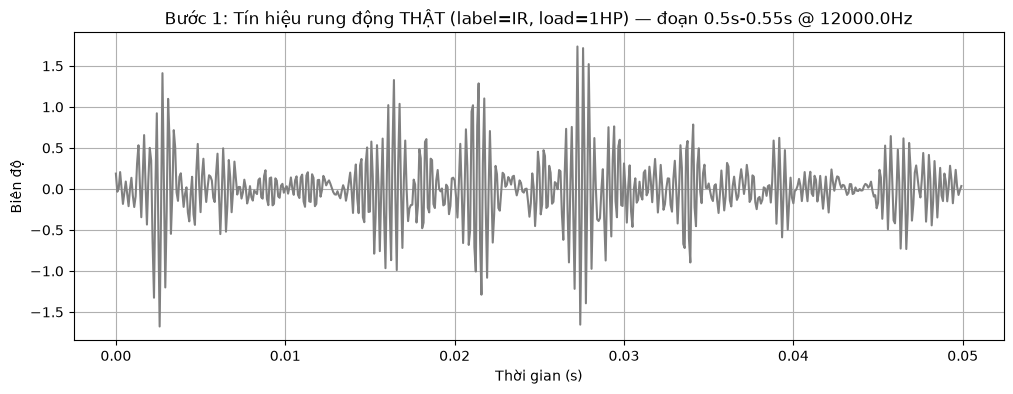

In [4]:
# 1. LẤY MỘT ĐOẠN TÍN HIỆU RUNG THẬT (Raw Vibration x[n])
DURATION_SEC = 0.05
START_SEC = 0.5  # bỏ qua đoạn đầu file cho an toàn

start_idx = int(START_SEC * fs)
n_samples = int(DURATION_SEC * fs)
x = x_full[start_idx:start_idx + n_samples]
t = np.arange(n_samples) / fs   # thời gian tương đối, bắt đầu từ 0 — để tương thích các cell phía dưới

plt.plot(t, x, color='gray')
plt.title(f"Bước 1: Tín hiệu rung động THẬT (label={LABEL}, load={LOAD_HP}HP) — "
         f"đoạn {START_SEC}s-{START_SEC+DURATION_SEC}s @ {fs}Hz")
plt.xlabel("Thời gian (s)")
plt.ylabel("Biên độ")
plt.show()

# 2. LỌC BAND-PASS 
**(Dùng RESONANCE_BAND_HZ)**

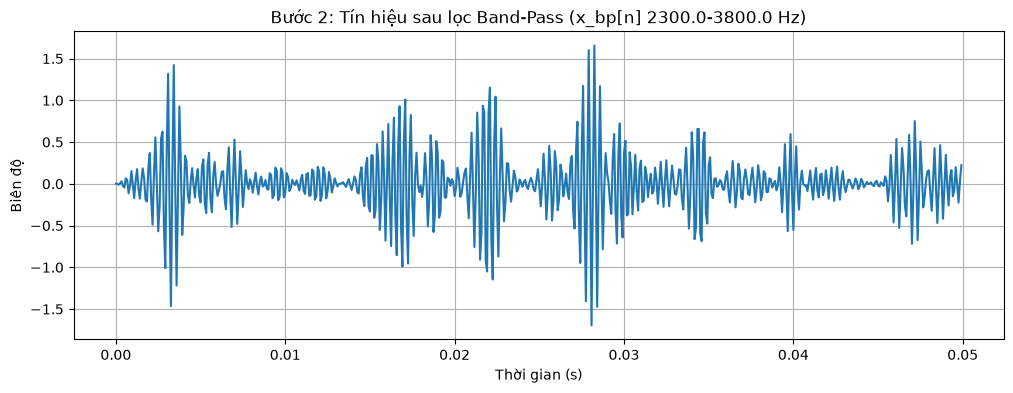

In [5]:
# 2. LỌC BAND-PASS
low_hz, high_hz = RESONANCE_BAND_HZ
nyq = fs / 2.0
wn = [low_hz / nyq, high_hz / nyq]

# Bộ lọc nhân quả Butterworth với bậc lấy từ dsp.py (mặc định bậc 4)
sos_bp = butter(BENCHMARK_BANDPASS_ORDER, wn, btype="bandpass", output="sos")
x_bp = sosfilt(sos_bp, x)

plt.plot(t, x_bp, color='C0')
plt.title(f"Bước 2: Tín hiệu sau lọc Band-Pass (x_bp[n] {low_hz}-{high_hz} Hz)")
plt.xlabel("Thời gian (s)")
plt.ylabel("Biên độ")
plt.show()

# Dịch pha trực giao nhân quả

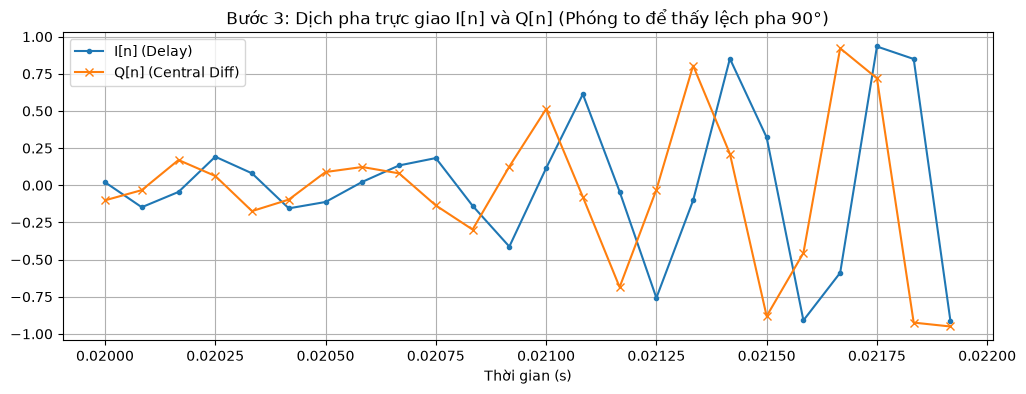

In [6]:
# 3. TẠO NHÁNH I VÀ Q
w_c = 2.0 * np.pi * fc / fs
sin_wc = np.sin(w_c)

if abs(sin_wc) < 1e-8:  # phòng chia 0 khi fc ~ 0 hoặc fc ~ fs/2
    sin_wc = 1e-8
    
i_ch = np.zeros(n_samples, dtype=np.float64)
q_ch = np.zeros(n_samples, dtype=np.float64)  
# Nhánh I: Delay 1 mẫu
i_ch[1:] = x_bp[:-1]

# Nhánh Q: Sai phân trung tâm chuẩn hóa (trễ 1 mẫu)
q_ch[2:] = (x_bp[2:] - x_bp[:-2]) / (2.0 * sin_wc) # type: ignore

# Zoom vào 2ms để quan sát độ lệch pha 90 độ (I và Q)
zoom_idx = int(0.02 * fs), int(0.022 * fs)
t_zoom = t[zoom_idx[0]:zoom_idx[1]]

plt.plot(t_zoom, i_ch[zoom_idx[0]:zoom_idx[1]], label="I[n] (Delay)", marker='.')
plt.plot(t_zoom, q_ch[zoom_idx[0]:zoom_idx[1]], label="Q[n] (Central Diff)", marker='x')
plt.title("Bước 3: Dịch pha trực giao I[n] và Q[n] (Phóng to để thấy lệch pha 90°)")
plt.xlabel("Thời gian (s)")
plt.legend()
plt.show()

# Trị tuyệt đối và tìm Max / Min

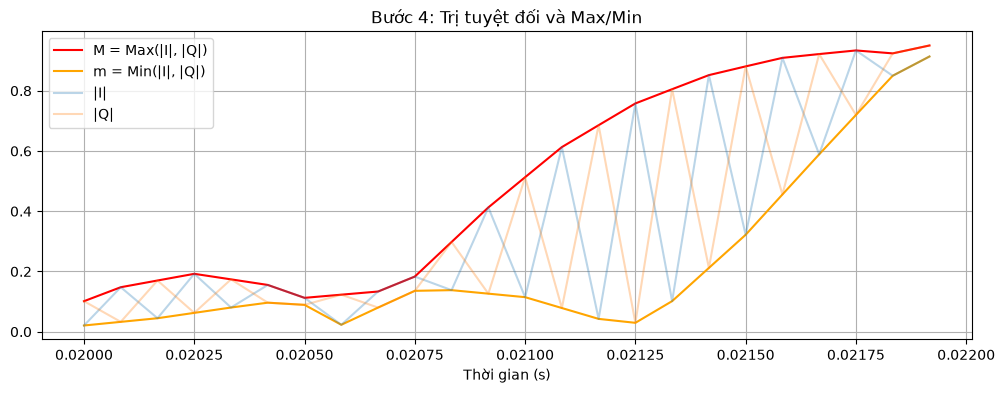

In [7]:
# 4. TRỊ TUYỆT ĐỐI & MAX/MIN
abs_i = np.abs(i_ch)
abs_q = np.abs(q_ch)

M_val = np.maximum(abs_i, abs_q)
m_val = np.minimum(abs_i, abs_q)

plt.plot(t_zoom, M_val[zoom_idx[0]:zoom_idx[1]], label="M = Max(|I|, |Q|)", color='red')
plt.plot(t_zoom, m_val[zoom_idx[0]:zoom_idx[1]], label="m = Min(|I|, |Q|)", color='orange')
plt.plot(t_zoom, abs_i[zoom_idx[0]:zoom_idx[1]], label="|I|", alpha=0.3)
plt.plot(t_zoom, abs_q[zoom_idx[0]:zoom_idx[1]], label="|Q|", alpha=0.3)
plt.title("Bước 4: Trị tuyệt đối và Max/Min")
plt.xlabel("Thời gian (s)")
plt.legend()
plt.show()

# Xấp xỉ Alpha-Max Plus Beta-Min

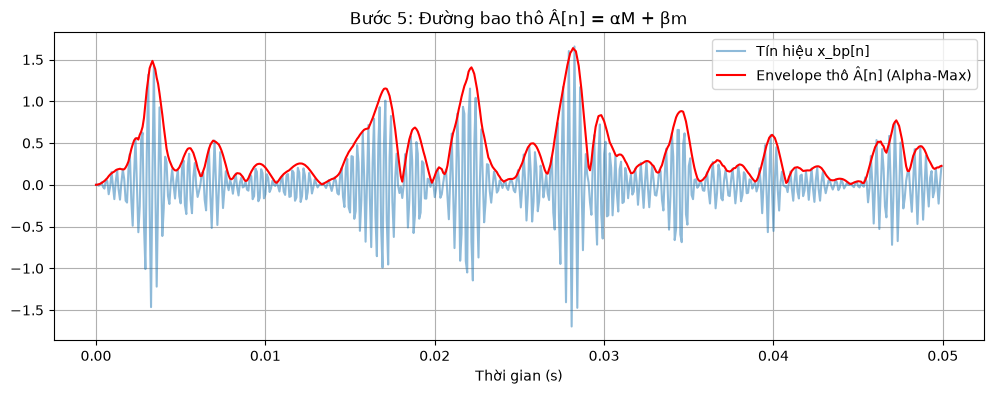

In [8]:
# 5. XẤP XỈ ALPHA-MAX PLUS BETA-MIN
# Lấy hệ số minmax từ dsp.py (α=0.9604, β=0.3978)
alpha = ALPHA_MAX_MINMAX
beta = BETA_MIN_MINMAX

abs_i, abs_q = np.abs(i_ch), np.abs(q_ch)

# Đường bao thô (chưa lọc)
env_raw = alpha * M_val + beta * m_val

plt.plot(t, x_bp, label="Tín hiệu x_bp[n]", color='C0', alpha=0.5)
plt.plot(t, env_raw, label="Envelope thô Â[n] (Alpha-Max)", color='red')
plt.title("Bước 5: Đường bao thô Â[n] = αM + βm")
plt.xlabel("Thời gian (s)")
plt.legend()
plt.show()

# Lọc Low-Pass và Khử DC

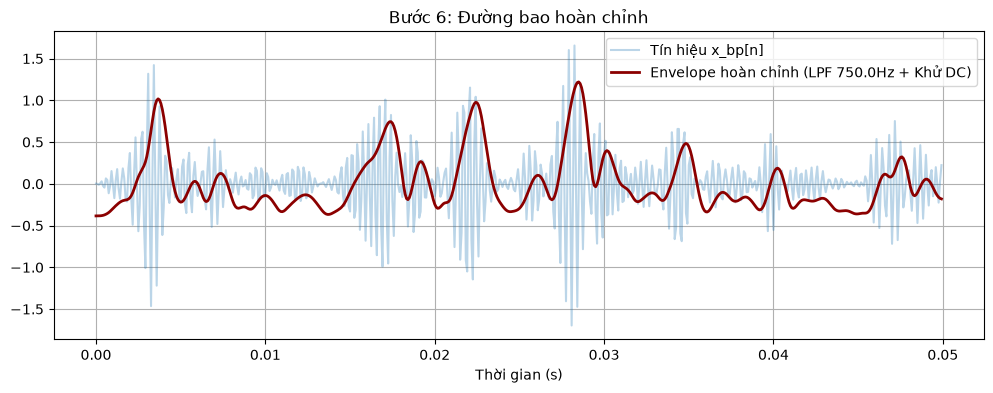

In [9]:
# 6. LỌC LOW-PASS VÀ KHỬ DC
# Lấy mốc cutoff (750Hz) từ config và order từ dsp
lp_cutoff = LP_CUTOFF_HZ 

# Bộ lọc nhân quả Butterworth
sos_lp = butter(BENCHMARK_LOWPASS_ORDER, lp_cutoff / nyq, btype="lowpass", output="sos")
env_smooth = sosfilt(sos_lp, env_raw)

# Khử thành phần DC
env_final = env_smooth - np.mean(env_smooth) # type: ignore

plt.plot(t, x_bp, label="Tín hiệu x_bp[n]", color='C0', alpha=0.3)
plt.plot(t, env_final, label=f"Envelope hoàn chỉnh (LPF {lp_cutoff}Hz + Khử DC)", color='darkred', linewidth=2)
plt.title("Bước 6: Đường bao hoàn chỉnh")
plt.xlabel("Thời gian (s)")
plt.legend()
plt.show()

# 7. CHẠY dsp.hybrid_envelope() TRÊN TOÀN BỘ FILE THẬT + SO VỚI TẦN SỐ LỖI LÝ THUYẾT

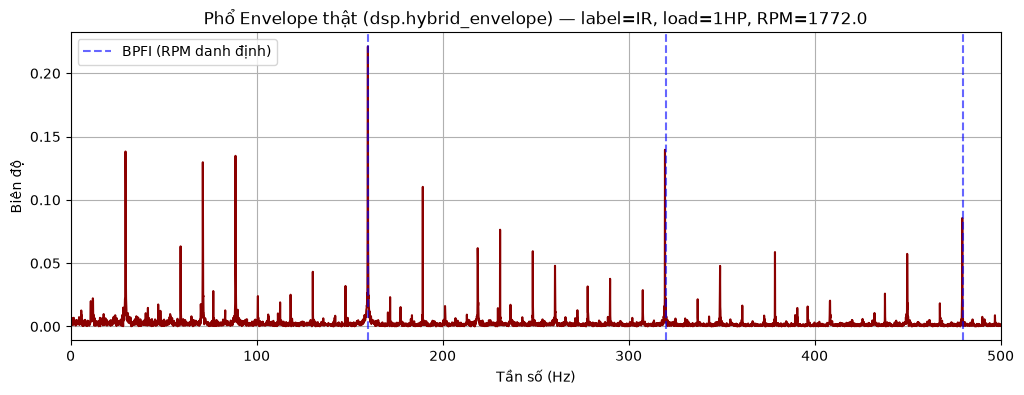

Tần số lỗi lý thuyết BPFI: 159.93 Hz (hài 2: 319.86 Hz, hài 3: 479.79 Hz)


In [16]:
env_full = hybrid_envelope(x_full, fs, band=RESONANCE_BAND_HZ)
freqs, mag = compute_fft(env_full - env_full.mean(), fs)

fault_freqs = bearing_fault_frequencies(rpm)
target_key = {"IR": "BPFI", "OR": "BPFO", "B": "BSF"}.get(LABEL)

plt.figure(figsize=(12, 4))
plt.plot(freqs, mag, color='darkred')
if target_key:
    f_fault = fault_freqs[target_key]
    for h in (1, 2, 3):
        plt.axvline(f_fault * h, color='blue', linestyle='--', alpha=0.6,
                    label=f"{target_key} (RPM danh định)" if h == 1 else None)
    plt.legend()
plt.xlim(0, 500)
plt.title(f"Phổ Envelope thật (dsp.hybrid_envelope) — "
         f"label={LABEL}, load={LOAD_HP}HP, RPM={rpm}")
plt.xlabel("Tần số (Hz)")
plt.ylabel("Biên độ")
plt.show()

if target_key:
    print(f"Tần số lỗi lý thuyết {target_key}: {fault_freqs[target_key]:.2f} Hz "
         f"(hài 2: {fault_freqs[target_key]*2:.2f} Hz, hài 3: {fault_freqs[target_key]*3:.2f} Hz)")
else:
    print("Normal: không có tần số lỗi mục tiêu để đối chiếu.")

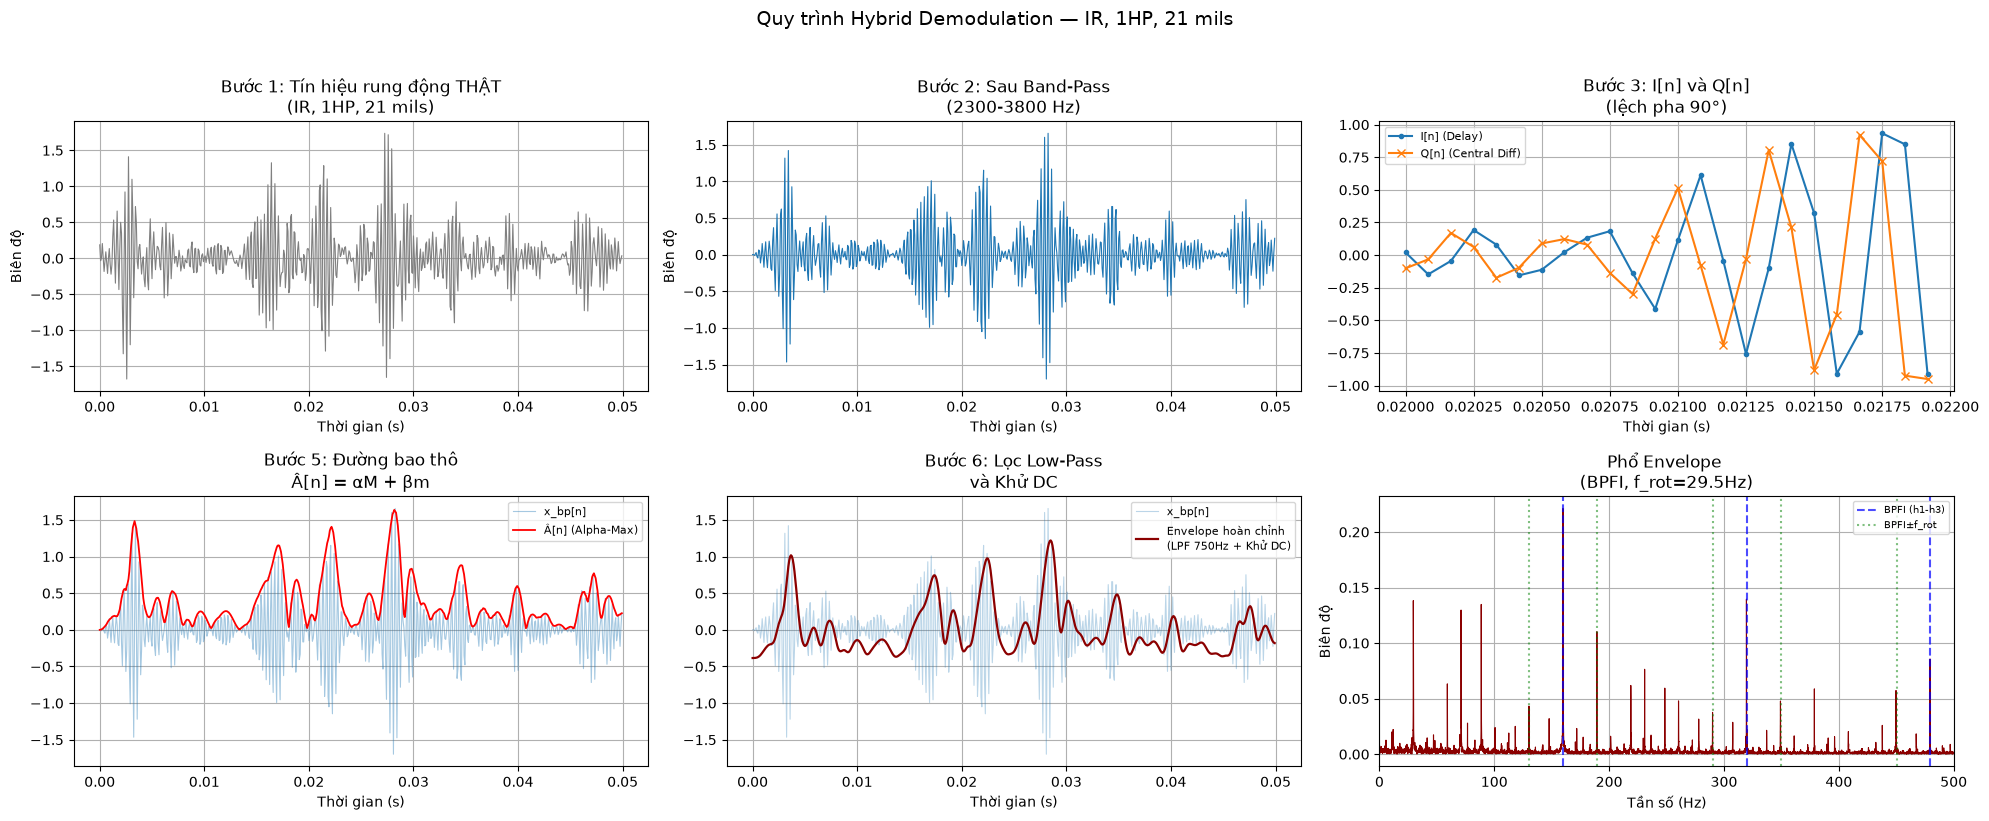

Đã lưu: ..\outputs\figures\00_hybrid_pipeline_IR_1hp_21mils.png


In [18]:
# ===== HÌNH TỔNG HỢP GIAI ĐOẠN 1: Quy trình Hybrid Demodulation =====
# Ghép Bước 1, 2, 3, 5, 6 và phổ Envelope toàn file (Bước 7) thành 1 hình 2x3,
# thêm chú thích dải biên điều chế (f_fault*h ± f_rot) trên phổ, và lưu ra
# file cho báo cáo. Chạy SAU cell Bước 7 vì dùng lại freqs/mag/fault_freqs.

FIGURES_DIR = OUTPUT_DIR / "figures"   # OUTPUT_DIR = "../outputs" (khác "./outputs"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)  # của 01-06 - cân nhắc gộp về 1 chuẩn sau)

f_rot = rpm / 60.0

fig, axes = plt.subplots(2, 3, figsize=(20, 8))

# --- (0,0) Bước 1: Tín hiệu thô ---
ax = axes[0, 0]
ax.plot(t, x, color='gray', linewidth=0.8)
ax.set_title(f"Bước 1: Tín hiệu rung động THẬT\n({LABEL}, {LOAD_HP}HP, {DIAMETER_MILS} mils)")
ax.set_xlabel("Thời gian (s)"); ax.set_ylabel("Biên độ")

# --- (0,1) Bước 2: Sau Band-Pass ---
ax = axes[0, 1]
ax.plot(t, x_bp, color='C0', linewidth=0.8)
ax.set_title(f"Bước 2: Sau Band-Pass\n({low_hz:.0f}-{high_hz:.0f} Hz)")
ax.set_xlabel("Thời gian (s)"); ax.set_ylabel("Biên độ")

# --- (0,2) Bước 3: I/Q trực giao (zoom) ---
ax = axes[0, 2]
ax.plot(t_zoom, i_ch[zoom_idx[0]:zoom_idx[1]], label="I[n] (Delay)", marker='.')
ax.plot(t_zoom, q_ch[zoom_idx[0]:zoom_idx[1]], label="Q[n] (Central Diff)", marker='x')
ax.set_title("Bước 3: I[n] và Q[n]\n(lệch pha 90°)")
ax.set_xlabel("Thời gian (s)"); ax.legend(fontsize=8)

# --- (1,0) Bước 5: Đường bao thô Alpha-Max ---
ax = axes[1, 0]
ax.plot(t, x_bp, color='C0', alpha=0.4, linewidth=0.8, label="x_bp[n]")
ax.plot(t, env_raw, color='red', linewidth=1.3, label="Â[n] (Alpha-Max)")
ax.set_title("Bước 5: Đường bao thô\nÂ[n] = αM + βm")
ax.set_xlabel("Thời gian (s)"); ax.legend(fontsize=8)

# --- (1,1) Bước 6: Lọc Low-Pass và Khử DC ---
ax = axes[1, 1]
ax.plot(t, x_bp, color='C0', alpha=0.3, linewidth=0.8, label="x_bp[n]")
ax.plot(t, env_final, color='darkred', linewidth=1.6,
       label=f"Envelope hoàn chỉnh\n(LPF {lp_cutoff:.0f}Hz + Khử DC)")
ax.set_title("Bước 6: Lọc Low-Pass\nvà Khử DC")
ax.set_xlabel("Thời gian (s)"); ax.legend(fontsize=8)

# --- (1,2) Phổ Envelope toàn file + dải biên điều chế ---
ax = axes[1, 2]
ax.plot(freqs, mag, color='darkred', linewidth=0.8)
if target_key:
    f_fault = fault_freqs[target_key]
    labeled_main = labeled_side = False
    for h in (1, 2, 3):
        f_h = f_fault * h
        ax.axvline(f_h, color='blue', linestyle='--', alpha=0.7,
                   label=f"{target_key} (h1-h3)" if not labeled_main else None)
        labeled_main = True
        for sb in (f_h - f_rot, f_h + f_rot):
            if 0 < sb <= 500:
                ax.axvline(sb, color='green', linestyle=':', alpha=0.5,
                          label=f"{target_key}±f_rot" if not labeled_side else None)
                labeled_side = True
    ax.legend(fontsize=7, loc='upper right')
ax.set_xlim(0, 500)
ax.set_title(f"Phổ Envelope \n({target_key or 'Normal'}, f_rot={f_rot:.1f}Hz)")
ax.set_xlabel("Tần số (Hz)"); ax.set_ylabel("Biên độ")

fig.suptitle(f"Quy trình Hybrid Demodulation — {LABEL}, {LOAD_HP}HP, {DIAMETER_MILS} mils",
            fontsize=14, y=1.02)
plt.tight_layout()

out_path = FIGURES_DIR / f"00_hybrid_pipeline_{LABEL}_{LOAD_HP}hp_{DIAMETER_MILS}mils.png"
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Đã lưu: {out_path}")

# 8. Đo SAI SỐ THỰC TẾ — ước lượng H_Q/H_I(f) từ tín hiệu
So đáp ứng tần số **đo được** (Welch H1 estimator: H = Pqi/Pii) với đường
lý thuyết đã suy ra: `∠(H_Q/H_I)=90°` mọi tần số, `|H_Q/H_I|=sinω/sinωc`.

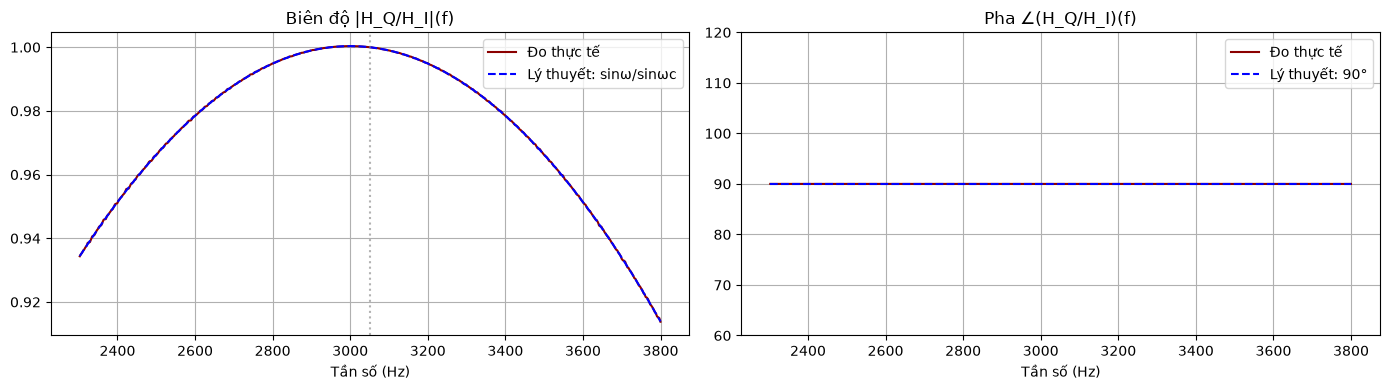

[label=IR, load=1HP, file=210_1.mat]
Sai số PHA đo được trong dải (2300.0, 3800.0): mean=+0.000°, max|lệch|=0.008°  (lý thuyết: 0.000°)
Sai số BIÊN ĐỘ đo được so với sinω/sinωc: mean=+0.00%, max|lệch|=0.05%


In [13]:
from scipy.signal import csd, welch

# Dùng TOÀN BỘ tín hiệu thật (không phải đoạn 50ms) để đủ dữ liệu ước lượng phổ
sos_bp_full = butter(BENCHMARK_BANDPASS_ORDER,
                     [RESONANCE_BAND_HZ[0]/(fs/2), RESONANCE_BAND_HZ[1]/(fs/2)],
                     btype="bandpass", output="sos")
x_bp_full = sosfilt(sos_bp_full, x_full)

i_full = np.zeros_like(x_bp_full)
q_full = np.zeros_like(x_bp_full)
i_full[1:] = x_bp_full[:-1]
q_full[2:] = (x_bp_full[2:] - x_bp_full[:-2]) / (2.0 * sin_wc) # type: ignore

# Ước lượng H1: H_Q/H_I(f) ~= Pqi(f) / Pii(f)  (I là "input", Q là "output")
NPERSEG = 4096
f_axis, Pqi = csd(i_full, q_full, fs=fs, nperseg=NPERSEG)
_,      Pii = welch(i_full,        fs=fs, nperseg=NPERSEG)
H_ratio = Pqi / Pii

mask = (f_axis >= RESONANCE_BAND_HZ[0]) & (f_axis <= RESONANCE_BAND_HZ[1])
f_band = f_axis[mask]
mag_meas = np.abs(H_ratio[mask])
phase_meas_deg = np.degrees(np.angle(H_ratio[mask]))

# --- Đường LÝ THUYẾT tương ứng ---
omega_band = 2 * np.pi * f_band / fs
mag_theory = np.sin(omega_band) / sin_wc
phase_theory_deg = np.full_like(f_band, 90.0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(f_band, mag_meas, color='darkred', label="Đo thực tế")
axes[0].plot(f_band, mag_theory, '--', color='blue', label="Lý thuyết: sinω/sinωc")
axes[0].axvline(fc, color='gray', linestyle=':', alpha=0.6)
axes[0].set_title("Biên độ |H_Q/H_I|(f)"); axes[0].set_xlabel("Tần số (Hz)"); axes[0].legend()

axes[1].plot(f_band, phase_meas_deg, color='darkred', label="Đo thực tế")
axes[1].plot(f_band, phase_theory_deg, '--', color='blue', label="Lý thuyết: 90°")
axes[1].set_ylim(60, 120)
axes[1].set_title("Pha ∠(H_Q/H_I)(f)"); axes[1].set_xlabel("Tần số (Hz)"); axes[1].legend()
plt.tight_layout(); plt.show()

# --- SAI SỐ THỰC TẾ (số liệu, không phải hình vẽ) ---
phase_err_deg = phase_meas_deg - 90.0
amp_err_pct = (mag_meas / mag_theory - 1.0) * 100.0

print(f"[label={LABEL}, load={LOAD_HP}HP, file={Path(file_path).name}]")
print(f"Sai số PHA đo được trong dải {RESONANCE_BAND_HZ}: "
     f"mean={phase_err_deg.mean():+.3f}°, max|lệch|={np.max(np.abs(phase_err_deg)):.3f}°  "
     f"(lý thuyết: 0.000°)")
print(f"Sai số BIÊN ĐỘ đo được so với sinω/sinωc: "
     f"mean={amp_err_pct.mean():+.2f}%, max|lệch|={np.max(np.abs(amp_err_pct)):.2f}%")

# 9. Sai số THỰC TẾ của toàn bộ pipeline Alpha-Max — so với 3.96% (AMBM) / 6.38% (kết hợp)
Dùng đúng i_full, q_full đã tính ở Bước 8 (không lọc thông thấp) — so `env_ambm`
(công thức Alpha-Max Plus Beta-Min) với biên độ THẬT `sqrt(I²+Q²)` điểm theo điểm.

[label=IR, load=1HP, file=210_1.mat]
Số điểm dùng để đo: 121,487 / 121,554 (loại 67 điểm biên độ < 0.006026)
Sai số Alpha-Max ĐO THỰC TẾ: mean=+1.306%, std=2.365%, max|lệch|=3.957%
So với lý thuyết: AMBM thuần (ωc, θ bất kỳ) = 3.96%  |  kết hợp với độ nghiêng I/Q tại fc=3050Hz (hiện tại) = 6.38%


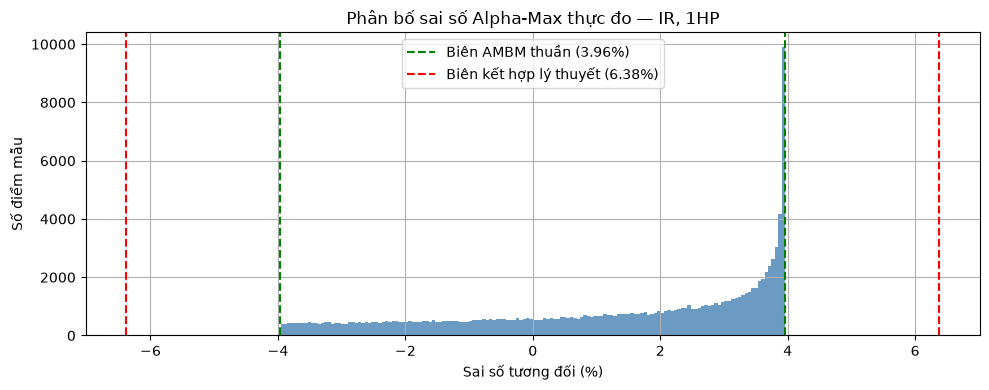

In [14]:
# Bỏ 2 mẫu đầu (transient của sai phân trung tâm, i_full/q_full = 0 ở đó)
abs_i = np.abs(i_full[2:])
abs_q = np.abs(q_full[2:])

env_ambm_raw = alpha * np.maximum(abs_i, abs_q) + beta * np.minimum(abs_i, abs_q)
env_true_raw = np.sqrt(i_full[2:] ** 2 + q_full[2:] ** 2)

# Bỏ qua các điểm biên độ quá nhỏ (gần 0-crossing của cả 2 kênh) để sai số
# tương đối không bị nhiễu chia-cho-số-rất-nhỏ — ngưỡng = 1% RMS tín hiệu.
floor = 0.01 * np.sqrt(np.mean(env_true_raw ** 2))
mask = env_true_raw > floor
rel_err_pct = (env_ambm_raw[mask] - env_true_raw[mask]) / env_true_raw[mask] * 100.0

print(f"[label={LABEL}, load={LOAD_HP}HP, file={Path(file_path).name}]")
print(f"Số điểm dùng để đo: {mask.sum():,} / {len(mask):,} "
     f"(loại {(~mask).sum():,} điểm biên độ < {floor:.4g})")
print(f"Sai số Alpha-Max ĐO THỰC TẾ: mean={rel_err_pct.mean():+.3f}%, "
     f"std={rel_err_pct.std():.3f}%, max|lệch|={np.max(np.abs(rel_err_pct)):.3f}%")
print(f"So với lý thuyết: AMBM thuần (ωc, θ bất kỳ) = 3.96%  |  "
     f"kết hợp với độ nghiêng I/Q tại fc=3050Hz (hiện tại) = 6.38%")

plt.figure(figsize=(10, 4))
plt.hist(rel_err_pct, bins=150, color='steelblue', alpha=0.8)
for v, lbl, c in [(3.96, "Biên AMBM thuần (3.96%)", "green"),
                  (6.38, "Biên kết hợp lý thuyết (6.38%)", "red")]:
    plt.axvline(v, color=c, linestyle='--', label=lbl)
    plt.axvline(-v, color=c, linestyle='--')
plt.title(f"Phân bố sai số Alpha-Max thực đo — {LABEL}, {LOAD_HP}HP")
plt.xlabel("Sai số tương đối (%)"); plt.ylabel("Số điểm mẫu")
plt.legend(); plt.tight_layout(); plt.show()

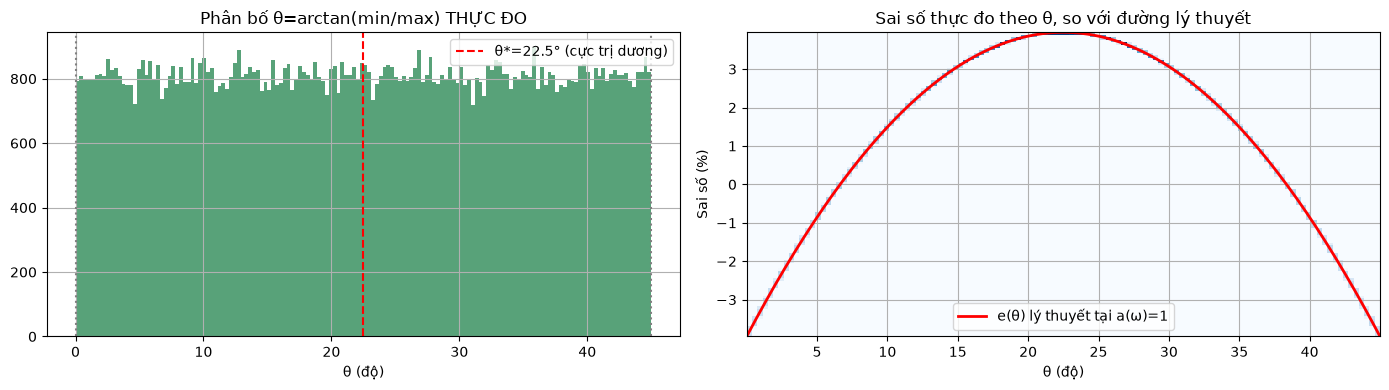

In [15]:
theta_deg = np.degrees(np.arctan2(np.minimum(abs_i, abs_q), np.maximum(abs_i, abs_q)))[mask]

# Đường cong lý thuyết e(θ) (tại a(ω)=1, tức đúng ngay fc — chưa tính độ nghiêng)
theta_curve = np.linspace(0, 45, 200)
e_curve_pct = (alpha * np.cos(np.radians(theta_curve)) + beta * np.sin(np.radians(theta_curve)) - 1.0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(theta_deg, bins=150, color='seagreen', alpha=0.8)
axes[0].axvline(22.5, color='red', linestyle='--', label='θ*=22.5° (cực trị dương)')
axes[0].axvline(0, color='gray', linestyle=':'); axes[0].axvline(45, color='gray', linestyle=':')
axes[0].set_title("Phân bố θ=arctan(min/max) THỰC ĐO")
axes[0].set_xlabel("θ (độ)"); axes[0].legend()

h = axes[1].hist2d(theta_deg, rel_err_pct, bins=[120, 120], cmap='Blues')
axes[1].plot(theta_curve, e_curve_pct, color='red', linewidth=2, label="e(θ) lý thuyết tại a(ω)=1")
axes[1].set_title("Sai số thực đo theo θ, so với đường lý thuyết")
axes[1].set_xlabel("θ (độ)"); axes[1].set_ylabel("Sai số (%)"); axes[1].legend()
plt.tight_layout(); plt.show()